In [1]:
import pandas as pd
import numpy as np
from catnip.fla_redshift import FLA_Redshift
from sqlalchemy import null
from datetime import datetime, timedelta
import polars as pl

from prefect.blocks.system import Secret
from typing import Dict
from concurrent.futures import ThreadPoolExecutor

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def get_redshift_credentials() -> Dict:

    cred_dict = {
        "dbname": Secret.load("stellar-redshift-db-name").get(),
        "host": Secret.load("stellar-redshift-host").get(),
        "port": 5439,
        "user": Secret.load("stellar-redshift-user-name").get(),
        "password": Secret.load("stellar-redshift-password").get(),

        "aws_access_key_id": Secret.load("fla-s3-aws-access-key-id-east-1").get(),
        "aws_secret_access_key": Secret.load("fla-s3-aws-secret-access-key-east-1").get(),
        "bucket": Secret.load("fla-s3-bucket-name-east-1").get(),
        "subdirectory": "us-east-1",

        "verbose": False,
    }

    return cred_dict

with ThreadPoolExecutor(1) as pool:
    rs_creds = pool.submit(lambda: get_redshift_credentials()).result()

In [ ]:
# -- =============================================================================
# -- LEAD SCORING — SEASON COHORT APPROACH
# --
# -- Logic:
# --   1. Base cohort = anyone who attended 1+ games in the OBSERVATION season
# --      who was NOT already a Full/Premier season ticket holder that same season
# --   2. Features = all engagement data collected during the observation season
# --   3. Label (did_purchase_next_season) = did they buy a Full/Premier new
# --      season ticket the FOLLOWING season?
# --
# -- Two training cohorts are stacked:
# --   Cohort A: observed in 23-24  →  label from 24-25
# --   Cohort B: observed in 24-25  →  label from 25-26
# --
# -- NHL season date ranges used for filtering:
# --   23-24:  2023-10-01 – 2024-06-30
# --   24-25:  2024-10-01 – 2025-06-30
# --   25-26:  2025-10-01 – present
# -- =============================================================================

q = """
WITH
-- ── Season ticket holders by season (used to exclude from cohort + build label) ──
members_2324 AS (
    SELECT DISTINCT
        purch_client_crm_id
    FROM
        custom.cth_v_ticket_subscription_2324
    WHERE
        ticket_type IN ('Full', 'Premier')
),
members_2425 AS (
    SELECT DISTINCT
        purch_client_crm_id
    FROM
        custom.cth_v_ticket_subscription_2425
    WHERE
        ticket_type IN ('Full', 'Premier')
),

-- New buyers only (non-renewals) — used for the label
new_buyers_2425 AS (
    SELECT DISTINCT
        purch_client_crm_id
    FROM
        custom.cth_v_ticket_subscription_2425
    WHERE
        ticket_type IN ('Full', 'Premier')
        AND is_renewal = FALSE
),
new_buyers_2526 AS (
    SELECT DISTINCT
        purch_client_crm_id
    FROM
        custom.cth_v_ticket_subscription_2526
    WHERE
        ticket_type IN ('Full', 'Premier')
        AND is_renewal = FALSE
),

-- ── Cohort A: attended 1+ games in 23-24, was NOT a 23-24 member ──
cohort_2324 AS (
    SELECT
        ticketing_account_scanned AS base_id,
        '2023-24'                 AS obs_season,
        '2023-10-01'::date        AS season_start,
        '2024-06-30'::date        AS season_end
    FROM
        custom.cth_v_historical_attendance
    WHERE
        event_date BETWEEN '2023-10-01' AND '2024-06-30'
        AND ticketing_account_scanned NOT IN (SELECT purch_client_crm_id FROM members_2324)
    GROUP BY
        ticketing_account_scanned
),

-- ── Cohort B: attended 1+ games in 24-25, was NOT a 24-25 member ──
cohort_2425 AS (
    SELECT
        ticketing_account_scanned AS base_id,
        '2024-25'                 AS obs_season,
        '2024-10-01'::date        AS season_start,
        '2025-06-30'::date        AS season_end
    FROM
        custom.cth_v_historical_attendance
    WHERE
        event_date BETWEEN '2024-10-01' AND '2025-06-30'
        AND ticketing_account_scanned NOT IN (SELECT purch_client_crm_id FROM members_2425)
    GROUP BY
        ticketing_account_scanned
),

-- ── Stack cohorts with their label ──
all_cohorts AS (
    SELECT
        c.*,
        CASE WHEN nb.purch_client_crm_id IS NOT NULL THEN 1 ELSE 0 END AS did_purchase_next_season
    FROM
        cohort_2324 c
    LEFT JOIN
        new_buyers_2425 nb ON c.base_id = nb.purch_client_crm_id
    UNION ALL
    SELECT
        c.*,
        CASE WHEN nb.purch_client_crm_id IS NOT NULL THEN 1 ELSE 0 END AS did_purchase_next_season
    FROM
        cohort_2425 c
    LEFT JOIN
        new_buyers_2526 nb ON c.base_id = nb.purch_client_crm_id
),

-- ── SFMC email engagement — scoped to observation season ──
sfmc_ref AS (
    SELECT
        subs.subscriberkey,
        kc.primary_ticketing_id,
        ac.obs_season,
        ac.season_start,
        ac.season_end
    FROM
        custom.sfmc_all_subscribers_panthers subs
    LEFT JOIN
        custom.korepss_v_contacts kc
        ON lower(subs.emailaddress) = lower(kc.email)
    JOIN
        all_cohorts ac ON kc.primary_ticketing_id = ac.base_id
),
email_sends AS (
    SELECT 
        primary_ticketing_id, 
        obs_season, 
        COUNT(*) AS num_sent
    FROM 
        custom.sfmc_sent s
    JOIN 
        sfmc_ref r ON s.subscriberkey = r.subscriberkey
    WHERE 
        s.eventdate BETWEEN r.season_start AND r.season_end
        AND s.oybaccountid = 534003233
    GROUP BY 
        primary_ticketing_id, 
        obs_season
),
email_opens AS (
    SELECT 
        primary_ticketing_id, obs_season,
        COUNT(*) AS num_opens,
        SUM(CASE WHEN isunique THEN 1 ELSE 0 END) AS num_unique_opens
    FROM 
        custom.sfmc_opens o
    JOIN 
        sfmc_ref r ON o.subscriberkey = r.subscriberkey
    WHERE 
        o.eventdate BETWEEN r.season_start AND r.season_end
        AND o.oybaccountid = 534003233
    GROUP BY 
        primary_ticketing_id, 
        obs_season
),
email_clicks AS (
    SELECT 
        primary_ticketing_id, obs_season,
        COUNT(*) AS num_clicks,
        SUM(CASE WHEN isunique THEN 1 ELSE 0 END) AS num_unique_clicks
    FROM 
        custom.sfmc_clicks c
    JOIN 
        sfmc_ref r ON c.subscriberkey = r.subscriberkey
    WHERE 
        c.eventdate BETWEEN r.season_start AND r.season_end
        AND c.oybaccountid = 534003233
    GROUP BY 
        primary_ticketing_id, 
        obs_season
),
email_bounces AS (
    SELECT 
        primary_ticketing_id, 
        obs_season, 
        COUNT(*) AS num_bounces
    FROM 
        custom.sfmc_bounces b
    JOIN 
        sfmc_ref r ON b.subscriberkey = r.subscriberkey
    WHERE 
        b.eventdate BETWEEN r.season_start AND r.season_end
        AND b.isunique = TRUE
        AND b.oybaccountid = 534003233
    GROUP BY 
        primary_ticketing_id, 
        obs_season
),
email_not_sent AS (
    SELECT 
        primary_ticketing_id, 
        obs_season, 
        COUNT(*) AS num_not_sent
    FROM 
        custom.sfmc_not_sent_panthers nsp
    JOIN 
        sfmc_ref r ON nsp.subscriberkey = r.subscriberkey
    WHERE 
        nsp.eventdate BETWEEN r.season_start AND r.season_end
    GROUP BY 
        primary_ticketing_id, 
        obs_season
),
unsubscribed AS (
    SELECT 
        primary_ticketing_id, 
        obs_season
    FROM 
        custom.sfmc_all_subscribers_panthers subs
    JOIN 
        sfmc_ref r ON subs.subscriberkey = r.subscriberkey
    WHERE 
        subs.dateunsubscribed BETWEEN r.season_start AND r.season_end
    GROUP BY 
        primary_ticketing_id, 
        obs_season
),

-- ── Attendance features — scoped to observation season ──
attendance_features AS (
    SELECT
        ac.base_id,
        ac.obs_season,
        COUNT(DISTINCT a.event_date) AS num_games_attended,
        COUNT(a.event_date)          AS num_scans
    FROM 
        all_cohorts ac
    JOIN 
        custom.cth_v_historical_attendance a
        ON ac.base_id = a.ticketing_account_scanned
    WHERE 
        a.event_date BETWEEN ac.season_start AND ac.season_end
    GROUP BY 
        ac.base_id, 
        ac.obs_season
),

-- ── Teamshop — scoped to observation season ──
teamshop_features AS (
    SELECT
        ac.base_id,
        ac.obs_season,
        SUM(op.gross_revenue_itemized)  AS sum_teamshop_rev,
        COUNT(DISTINCT op.order_id)     AS num_teamshop_orders
    FROM 
        all_cohorts ac
    JOIN 
        custom.korepss_v_contacts kc ON ac.base_id = kc.primary_ticketing_id
    JOIN 
        custom.flateamshop_orders ord ON lower(kc.email) = lower(ord.bill_email)
    JOIN 
        custom.flateamshop_v_order_products op USING (order_id)
    WHERE 
        op.date_modified BETWEEN ac.season_start AND ac.season_end
    GROUP BY
        ac.base_id, 
        ac.obs_season
),

-- ── Digital engagement — scoped to observation season ──
formstack_features AS (
    SELECT
        ac.base_id,
        ac.obs_season,
        COUNT(DISTINCT s.submission_id) AS formstack_submissions
    FROM 
        all_cohorts ac
    JOIN 
        custom.korepss_v_contacts kc ON ac.base_id = kc.primary_ticketing_id
    JOIN 
        custom.formstack_v_ticket_product_submissions s ON lower(kc.email) = lower(s.email)
    WHERE 
        s.submission_timestamp BETWEEN ac.season_start AND ac.season_end
    GROUP BY
        ac.base_id, 
        ac.obs_season
),
tradable_bits_features AS (
    SELECT
        ac.base_id,
        ac.obs_season,
        COUNT(DISTINCT tb.activity_id) AS tradable_bits_activities
    FROM 
        all_cohorts ac
    JOIN 
        custom.korepss_v_contacts kc ON ac.base_id = kc.primary_ticketing_id
    JOIN 
        custom.tradable_bits_activities tb ON lower(kc.email) = lower(tb.email)
    WHERE 
        tb.creation_date BETWEEN ac.season_start AND ac.season_end
    GROUP BY 
        ac.base_id, 
        ac.obs_season
),
blade_features AS (
    SELECT
        ac.base_id,
        ac.obs_season,
        COUNT(DISTINCT (
            t.trnsctn_sub_typ || ' ' || t.trnsctn_sub_typ || ' ' || t.trnsctn_dtm::date
        )) AS blade_transactions
    FROM 
        all_cohorts ac
    JOIN 
        custom.korepss_v_contacts kc      ON ac.base_id = kc.primary_ticketing_id
    JOIN 
        custom.blade_v_identified_fans f  ON lower(kc.email) = lower(f.email_address)
    JOIN 
        custom.blade_xrf xrf              ON f.blade_id = xrf.blade_id
    JOIN 
        custom.blade_transactions t       ON xrf.acct_id = t.acct_id
    WHERE 
        t.trnsctn_dtm BETWEEN ac.season_start AND ac.season_end
        AND t.trnsctn_typ IS NOT NULL
        AND t.trnsctn_typ NOT ILIKE '%Preference%'
        AND t.trnsctn_typ NOT ILIKE '%update%'
        AND t.trnsctn_typ NOT ILIKE '%login%'
        AND t.dw_src_nm NOT IN ('Partner','Ticket Master','Sweet_NFTs','Upper Deck','Sobeys')
    GROUP BY 
        ac.base_id, 
        ac.obs_season
),
panthers_plus_features AS (
    SELECT DISTINCT
        ac.base_id,
        ac.obs_season,
        1 AS is_panthers_plus
    FROM 
        all_cohorts ac
    JOIN 
        custom.korepss_v_contacts kc ON ac.base_id = kc.primary_ticketing_id
    JOIN 
        custom.mailchimp_v_panthers_plus mpp ON lower(kc.email) = lower(mpp.email)
    WHERE
        mpp.timestamp_signup <= ac.season_end
),
postgame_survey_features AS (
    SELECT
        ac.base_id,
        ac.obs_season,
        COUNT(DISTINCT fpgs.event_date::date) AS postgame_survey_responses
    FROM 
        all_cohorts ac
    JOIN 
        custom.korepss_v_contacts kc ON ac.base_id = kc.primary_ticketing_id
    JOIN 
        custom.formstack_v_postgame_surveys_2425 fpgs ON lower(kc.email) = lower(fpgs.email)
    WHERE 
        fpgs.submission_timestamp BETWEEN ac.season_start AND ac.season_end
    GROUP BY 
        ac.base_id, 
        ac.obs_season
),

-- ── Geo — static, not season-scoped ──
geo AS (
    SELECT 
        kc.primary_ticketing_id, 
        ga.is_local::int
    FROM 
        custom.korepss_v_contacts kc
    LEFT JOIN 
        custom.golden_record_v_addresses ga ON lower(kc.email) = lower(ga.email)
    GROUP BY 
        kc.primary_ticketing_id, 
        ga.is_local::int
)

SELECT
    ac.base_id,
    ac.obs_season,
    ac.did_purchase_next_season,
    COALESCE(af.num_games_attended,       0)       AS num_games_attended,
    COALESCE(af.num_scans,                0)       AS num_scans,
    COALESCE(es.num_sent,                 0)       AS num_sent,
    COALESCE(eo.num_opens,                0)       AS num_opens,
    COALESCE(eo.num_unique_opens,         0)       AS num_unique_opens,
    COALESCE(ec.num_clicks,               0)       AS num_clicks,
    COALESCE(ec.num_unique_clicks,        0)       AS num_unique_clicks,
    COALESCE(eb.num_bounces,              0)       AS num_bounces,
    COALESCE(en.num_not_sent,             0)       AS num_not_sent,
    CASE WHEN u.primary_ticketing_id IS NOT NULL THEN 1 ELSE 0 END AS is_unsubscribed,
    COALESCE(ts.sum_teamshop_rev,         0)::int  AS sum_teamshop_rev,
    COALESCE(ts.num_teamshop_orders,      0)       AS num_teamshop_orders,
    COALESCE(ff.formstack_submissions,    0)       AS formstack_submissions,
    COALESCE(tb.tradable_bits_activities, 0)       AS tradable_bits_activities,
    COALESCE(bf.blade_transactions,       0)       AS blade_transactions,
    COALESCE(pp.is_panthers_plus,         0)       AS is_panthers_plus,
    COALESCE(pg.postgame_survey_responses, 0)      AS postgame_survey_responses,
    COALESCE(g.is_local,                  0)       AS is_local
FROM 
    all_cohorts ac
LEFT JOIN 
    attendance_features       af ON ac.base_id = af.base_id       AND ac.obs_season = af.obs_season
LEFT JOIN 
    email_sends               es ON ac.base_id = es.primary_ticketing_id AND ac.obs_season = es.obs_season
LEFT JOIN 
    email_opens               eo ON ac.base_id = eo.primary_ticketing_id AND ac.obs_season = eo.obs_season
LEFT JOIN 
    email_clicks              ec ON ac.base_id = ec.primary_ticketing_id AND ac.obs_season = ec.obs_season
LEFT JOIN 
    email_bounces             eb ON ac.base_id = eb.primary_ticketing_id AND ac.obs_season = eb.obs_season
LEFT JOIN 
    email_not_sent            en ON ac.base_id = en.primary_ticketing_id AND ac.obs_season = en.obs_season
LEFT JOIN 
    unsubscribed              u  ON ac.base_id = u.primary_ticketing_id  AND ac.obs_season = u.obs_season
LEFT JOIN 
    teamshop_features         ts ON ac.base_id = ts.base_id       AND ac.obs_season = ts.obs_season
LEFT JOIN 
    formstack_features        ff ON ac.base_id = ff.base_id       AND ac.obs_season = ff.obs_season
LEFT JOIN 
    tradable_bits_features    tb ON ac.base_id = tb.base_id       AND ac.obs_season = tb.obs_season
LEFT JOIN 
    blade_features            bf ON ac.base_id = bf.base_id       AND ac.obs_season = bf.obs_season
LEFT JOIN 
    panthers_plus_features    pp ON ac.base_id = pp.base_id       AND ac.obs_season = pp.obs_season
LEFT JOIN 
    postgame_survey_features  pg ON ac.base_id = pg.base_id       AND ac.obs_season = pg.obs_season
LEFT JOIN 
    geo                       g  ON ac.base_id = g.primary_ticketing_id"""

train_df = FLA_Redshift(**rs_creds).query_warehouse(sql_string=q)

In [ ]:
train_df.to_csv("C:\\Users\\riffere\\Desktop\\final_train_df.csv")

In [ ]:
q = """
WITH
members_2526 AS (
    SELECT DISTINCT 
        purch_client_crm_id
    FROM 
        custom.cth_v_ticket_subscription_2526
    WHERE 
        ticket_type IN ('Full', 'Premier')
),
inference_cohort AS (
    SELECT
        ticketing_account_scanned           AS base_id,
        '2025-26'                           AS obs_season,
        '2025-10-01'::date                  AS season_start,
        CURRENT_DATE                        AS season_end
    FROM 
        custom.cth_v_historical_attendance
    WHERE 
        event_date >= '2025-10-01'
        AND ticketing_account_scanned NOT IN (SELECT purch_client_crm_id FROM members_2526)
    GROUP BY 
        ticketing_account_scanned
),
sfmc_ref AS (
    SELECT
        subs.subscriberkey,
        kc.primary_ticketing_id,
        ic.obs_season,
        ic.season_start,
        ic.season_end
    FROM 
        custom.sfmc_all_subscribers_panthers subs
    LEFT JOIN 
        custom.korepss_v_contacts kc
        ON lower(subs.emailaddress) = lower(kc.email)
    JOIN 
        inference_cohort ic ON kc.primary_ticketing_id = ic.base_id
),
email_sends AS (
    SELECT 
        primary_ticketing_id, 
        COUNT(*) AS num_sent
    FROM 
        custom.sfmc_sent s
    JOIN 
        sfmc_ref r ON s.subscriberkey = r.subscriberkey
    WHERE 
        s.eventdate BETWEEN r.season_start AND r.season_end
        AND s.oybaccountid = 534003233
    GROUP BY 
        primary_ticketing_id
),
email_opens AS (
    SELECT 
        primary_ticketing_id,
        COUNT(*) AS num_opens,
        SUM(CASE WHEN isunique THEN 1 ELSE 0 END) AS num_unique_opens
    FROM 
        custom.sfmc_opens o
    JOIN 
        sfmc_ref r ON o.subscriberkey = r.subscriberkey
    WHERE 
        o.eventdate BETWEEN r.season_start AND r.season_end
        AND o.oybaccountid = 534003233
    GROUP BY 
        primary_ticketing_id
),
email_clicks AS (
    SELECT 
        primary_ticketing_id,
        COUNT(*) AS num_clicks,
        SUM(CASE WHEN isunique THEN 1 ELSE 0 END) AS num_unique_clicks
    FROM 
        custom.sfmc_clicks c
    JOIN 
        sfmc_ref r ON c.subscriberkey = r.subscriberkey
    WHERE 
        c.eventdate BETWEEN r.season_start AND r.season_end
        AND c.oybaccountid = 534003233
    GROUP BY 
        primary_ticketing_id
),
email_bounces AS (
    SELECT 
        primary_ticketing_id, 
        COUNT(*) AS num_bounces
    FROM 
        custom.sfmc_bounces b
    JOIN 
        sfmc_ref r ON b.subscriberkey = r.subscriberkey
    WHERE 
        b.eventdate BETWEEN r.season_start AND r.season_end
        AND b.isunique = TRUE
        AND b.oybaccountid = 534003233
    GROUP BY 
        primary_ticketing_id
),
email_not_sent AS (
    SELECT 
        primary_ticketing_id, 
        COUNT(*) AS num_not_sent
    FROM 
        custom.sfmc_not_sent_panthers nsp
    JOIN 
        sfmc_ref r ON nsp.subscriberkey = r.subscriberkey
    WHERE 
        nsp.eventdate BETWEEN r.season_start AND r.season_end
    GROUP BY 
        primary_ticketing_id
),
unsubscribed AS (
    SELECT 
        primary_ticketing_id
    FROM 
        custom.sfmc_all_subscribers_panthers subs
    JOIN 
        sfmc_ref r ON subs.subscriberkey = r.subscriberkey
    WHERE 
        subs.dateunsubscribed BETWEEN r.season_start AND r.season_end
    GROUP BY 
        primary_ticketing_id
),
attendance_features AS (
    SELECT
        ic.base_id,
        COUNT(DISTINCT a.event_date) AS num_games_attended,
        COUNT(a.event_date)          AS num_scans
    FROM 
        inference_cohort ic
    JOIN 
        custom.cth_v_historical_attendance a ON ic.base_id = a.ticketing_account_scanned
    WHERE 
        a.event_date BETWEEN ic.season_start AND ic.season_end
    GROUP BY 
        ic.base_id
),
teamshop_features AS (
    SELECT
        ic.base_id,
        SUM(op.gross_revenue_itemized) AS sum_teamshop_rev,
        COUNT(DISTINCT op.order_id)    AS num_teamshop_orders
    FROM 
        inference_cohort ic
    JOIN 
        custom.korepss_v_contacts kc ON ic.base_id = kc.primary_ticketing_id
    JOIN 
        custom.flateamshop_orders ord ON lower(kc.email) = lower(ord.bill_email)
    JOIN 
        custom.flateamshop_v_order_products op USING (order_id)
    WHERE 
        op.date_modified BETWEEN ic.season_start AND ic.season_end
    GROUP BY 
        ic.base_id
),
formstack_features AS (
    SELECT 
        ic.base_id, COUNT(DISTINCT s.submission_id) AS formstack_submissions
    FROM 
        inference_cohort ic
    JOIN 
        custom.korepss_v_contacts kc ON ic.base_id = kc.primary_ticketing_id
    JOIN 
        custom.formstack_v_ticket_product_submissions s ON lower(kc.email) = lower(s.email)
    WHERE 
        s.submission_timestamp BETWEEN ic.season_start AND ic.season_end
    GROUP BY 
        ic.base_id
),
tradable_bits_features AS (
    SELECT 
        ic.base_id, COUNT(DISTINCT tb.activity_id) AS tradable_bits_activities
    FROM 
        inference_cohort ic
    JOIN 
        custom.korepss_v_contacts kc ON ic.base_id = kc.primary_ticketing_id
    JOIN 
        custom.tradable_bits_activities tb ON lower(kc.email) = lower(tb.email)
    WHERE 
        tb.creation_date BETWEEN ic.season_start AND ic.season_end
    GROUP BY 
        ic.base_id
),
blade_features AS (
    SELECT
        ic.base_id,
        COUNT(DISTINCT (
            t.trnsctn_sub_typ || ' ' || t.trnsctn_sub_typ || ' ' || t.trnsctn_dtm::date
        )) AS blade_transactions
    FROM 
        inference_cohort ic
    JOIN 
        custom.korepss_v_contacts kc      ON ic.base_id = kc.primary_ticketing_id
    JOIN 
        custom.blade_v_identified_fans f  ON lower(kc.email) = lower(f.email_address)
    JOIN 
        custom.blade_xrf xrf              ON f.blade_id = xrf.blade_id
    JOIN 
        custom.blade_transactions t       ON xrf.acct_id = t.acct_id
    WHERE 
        t.trnsctn_dtm BETWEEN ic.season_start AND ic.season_end
        AND t.trnsctn_typ IS NOT NULL
        AND t.trnsctn_typ NOT ILIKE '%Preference%'
        AND t.trnsctn_typ NOT ILIKE '%update%'
        AND t.trnsctn_typ NOT ILIKE '%login%'
        AND t.dw_src_nm NOT IN ('Partner','Ticket Master','Sweet_NFTs','Upper Deck','Sobeys')
    GROUP BY 
        ic.base_id
),
panthers_plus_features AS (
    SELECT DISTINCT 
        ic.base_id, 1 AS is_panthers_plus
    FROM 
        inference_cohort ic
    JOIN custom.korepss_v_contacts kc ON ic.base_id = kc.primary_ticketing_id
    JOIN 
        custom.mailchimp_v_panthers_plus mpp ON lower(kc.email) = lower(mpp.email)
    WHERE 
        mpp.timestamp_signup <= ic.season_end
),
postgame_survey_features AS (
    SELECT 
        ic.base_id, 
        COUNT(DISTINCT fpgs.event_date::date) AS postgame_survey_responses
    FROM 
        inference_cohort ic
    JOIN 
        custom.korepss_v_contacts kc ON ic.base_id = kc.primary_ticketing_id
    JOIN 
        custom.formstack_v_postgame_surveys_2425 fpgs ON lower(kc.email) = lower(fpgs.email)
    WHERE 
        fpgs.submission_timestamp BETWEEN ic.season_start AND ic.season_end
    GROUP BY 
        ic.base_id
),
geo AS (
    SELECT 
        kc.primary_ticketing_id, ga.is_local::int
    FROM 
        custom.korepss_v_contacts kc
    LEFT JOIN 
        custom.golden_record_v_addresses ga ON lower(kc.email) = lower(ga.email)
    GROUP BY 
        kc.primary_ticketing_id, ga.is_local::int
)

SELECT
    ic.base_id,
    ic.obs_season,
    COALESCE(af.num_games_attended,       0)       AS num_games_attended,
    COALESCE(af.num_scans,                0)       AS num_scans,
    COALESCE(es.num_sent,                 0)       AS num_sent,
    COALESCE(eo.num_opens,                0)       AS num_opens,
    COALESCE(eo.num_unique_opens,         0)       AS num_unique_opens,
    COALESCE(ec.num_clicks,               0)       AS num_clicks,
    COALESCE(ec.num_unique_clicks,        0)       AS num_unique_clicks,
    COALESCE(eb.num_bounces,              0)       AS num_bounces,
    COALESCE(en.num_not_sent,             0)       AS num_not_sent,
    CASE WHEN u.primary_ticketing_id IS NOT NULL THEN 1 ELSE 0 END AS is_unsubscribed,
    COALESCE(ts.sum_teamshop_rev,         0)::int  AS sum_teamshop_rev,
    COALESCE(ts.num_teamshop_orders,      0)       AS num_teamshop_orders,
    COALESCE(ff.formstack_submissions,    0)       AS formstack_submissions,
    COALESCE(tb.tradable_bits_activities, 0)       AS tradable_bits_activities,
    COALESCE(bf.blade_transactions,       0)       AS blade_transactions,
    COALESCE(pp.is_panthers_plus,         0)       AS is_panthers_plus,
    COALESCE(pg.postgame_survey_responses, 0)      AS postgame_survey_responses,
    COALESCE(g.is_local,                  0)       AS is_local
FROM 
    inference_cohort ic
LEFT JOIN 
    attendance_features       af ON ic.base_id = af.base_id
LEFT JOIN 
    email_sends               es ON ic.base_id = es.primary_ticketing_id
LEFT JOIN 
    email_opens               eo ON ic.base_id = eo.primary_ticketing_id
LEFT JOIN 
    email_clicks              ec ON ic.base_id = ec.primary_ticketing_id
LEFT JOIN 
    email_bounces             eb ON ic.base_id = eb.primary_ticketing_id
LEFT JOIN 
    email_not_sent            en ON ic.base_id = en.primary_ticketing_id
LEFT JOIN 
    unsubscribed              u  ON ic.base_id = u.primary_ticketing_id
LEFT JOIN 
    teamshop_features         ts ON ic.base_id = ts.base_id
LEFT JOIN 
    formstack_features        ff ON ic.base_id = ff.base_id
LEFT JOIN 
    tradable_bits_features    tb ON ic.base_id = tb.base_id
LEFT JOIN 
    blade_features            bf ON ic.base_id = bf.base_id
LEFT JOIN 
    panthers_plus_features    pp ON ic.base_id = pp.base_id
LEFT JOIN 
    postgame_survey_features  pg ON ic.base_id = pg.base_id
LEFT JOIN 
    geo                       g  ON ic.base_id = g.primary_ticketing_id;
"""
test_df = FLA_Redshift(**rs_creds).query_warehouse(sql_string=q)

In [ ]:
test_df.to_csv("C:\\Users\\riffere\\Desktop\\final_test_df.csv")

In [ ]:
final_train_df = pd.read_csv("C:\\Users\\riffere\\Desktop\\final_train_df.csv")

final_test_df = pd.read_csv("C:\\Users\\riffere\\Desktop\\final_test_df.csv")

In [4]:
final_test_df

,Unnamed: 0,base_id,num_games_attended,num_attended,sum_teamshop_rev,num_teamshop_orders,is_local,email,formstack_submissions,tradable_bits_activities,...,is_panthers_plus,postgame_survey_responses,is_unsubscribed,num_sent,num_opens,num_unique_opens,num_clicks,num_unique_clicks,num_bounces,num_not_sent_panthers
0,0,15851691,47,93,49,1,1,mlr.rossner@aol.com,2.0,0.0,...,0.0,0.0,0.0,271.0,56.0,56.0,11.0,10.0,6.0,0.0
1,1,18686894,8,20,434,1,1,ariel.rose0804@gmail.com,1.0,0.0,...,0.0,0.0,0.0,366.0,446.0,339.0,4.0,4.0,0.0,0.0
2,2,13522859,2,4,0,0,1,chikita_216@hotmail.com,0.0,0.0,...,0.0,0.0,0.0,11.0,9.0,9.0,0.0,0.0,0.0,0.0
3,3,21365287,9,17,0,0,1,aherrera72990@yahoo.com,0.0,2.0,...,0.0,0.0,1.0,138.0,7.0,5.0,4.0,2.0,0.0,95.0
4,4,16057691,12,33,0,0,1,estockel@outlook.com,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515514,515514,25553713,0,0,0,0,1,dpenapr@yahoo.com,0.0,0.0,...,0.0,0.0,1.0,179.0,8.0,7.0,4.0,3.0,0.0,48.0
515515,515515,18595991,0,0,0,0,1,wheatleyh@sanzafood.com,0.0,0.0,...,0.0,0.0,1.0,12.0,8.0,4.0,8.0,3.0,0.0,169.0
515516,515516,25689538,0,0,42,1,0,dana.adams93@yahoo.com,0.0,0.0,...,0.0,0.0,1.0,27.0,29.0,15.0,11.0,7.0,1.0,145.0
515517,515517,25828923,0,0,30,1,1,shapiroc@floridapanthers.com,0.0,0.0,...,0.0,0.0,0.0,173.0,179.0,60.0,20.0,9.0,0.0,0.0


In [14]:
y_train = final_train_df[['did_purchase']]
x_train = final_train_df.drop(labels = ['did_purchase','base_id','email','num_unique_clicks','num_unique_opens','sum_teamshop_rev'], axis = 1)

x_test = final_test_df.drop(labels = ['base_id','email','num_unique_clicks','num_unique_opens','sum_teamshop_rev'], axis = 1)

# Handle Imbalance (The 'Quasar' Ratio)
# Calculate how many 0s there are for every 1
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Initialize and Train
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=float(ratio), # This makes the model 'care' more about the rare buyers
    eval_metric="logloss"
)

model.fit(x_train, y_train)

C:\Users\riffere\AppData\Local\Temp\ipykernel_26676\1784006490.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  scale_pos_weight=float(ratio), # This makes the model 'care' more about the rare buyers


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

score: 0.9396028561910693


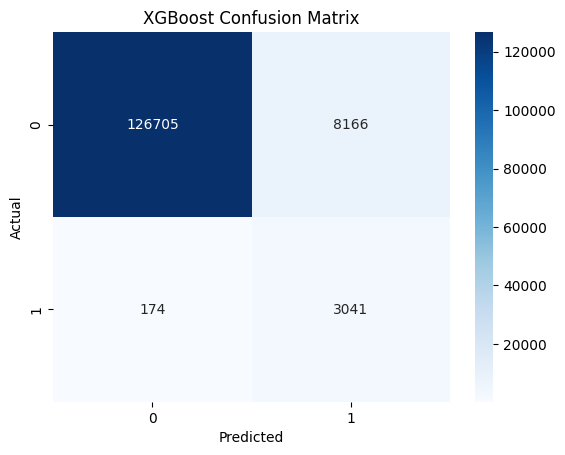

In [15]:
print('score:', model.score(x_train, y_train))

y_pred = model.predict(x_train)

cm = confusion_matrix(y_true=y_train, y_pred=y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

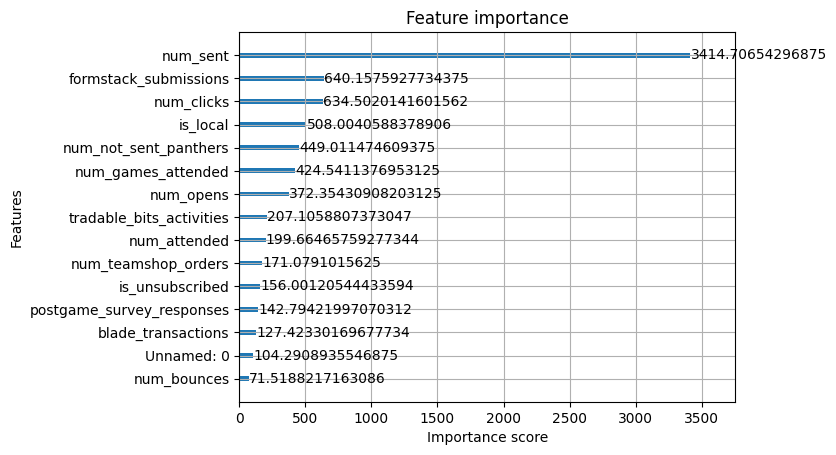

In [16]:
from xgboost import plot_importance

importances = model.feature_importances_
plot_importance(model, importance_type="gain")

In [17]:
corr_matrix = x_test.corr(method="pearson")   # or "spearman"

corr_matrix

,Unnamed: 0,num_games_attended,num_attended,num_teamshop_orders,is_local,formstack_submissions,tradable_bits_activities,blade_transactions,is_panthers_plus,postgame_survey_responses,is_unsubscribed,num_sent,num_opens,num_clicks,num_bounces,num_not_sent_panthers
Unnamed: 0,1.000000,-0.233319,-0.199646,-0.034122,-0.016053,-0.039251,-0.051337,-0.056019,NaN,-0.018829,-0.105437,-0.164147,-0.101116,-0.012739,-0.037419,-0.124451
num_games_attended,-0.233319,1.000000,0.770414,0.160091,0.152916,0.137646,0.202381,0.150995,NaN,0.210311,-0.033682,0.340031,0.257247,0.054017,0.038930,0.030826
num_attended,-0.199646,0.770414,1.000000,0.119259,0.117423,0.115091,0.149385,0.117604,NaN,0.158353,-0.028162,0.264614,0.201937,0.041179,0.030398,0.024620
num_teamshop_orders,-0.034122,0.160091,0.119259,1.000000,0.051062,0.063510,0.153629,0.213045,NaN,0.086889,-0.032695,0.182409,0.157210,0.038263,0.019527,-0.004582
is_local,-0.016053,0.152916,0.117423,0.051062,1.000000,0.063360,0.080906,0.090817,NaN,0.059480,-0.079530,0.162927,0.115047,0.012179,0.017728,-0.021538
formstack_submissions,-0.039251,0.137646,0.115091,0.063510,0.063360,1.000000,0.124262,0.090619,NaN,0.101409,-0.017874,0.141574,0.112105,0.029807,0.013553,0.002967
tradable_bits_activities,-0.051337,0.202381,0.149385,0.153629,0.080906,0.124262,1.000000,0.160895,NaN,0.210005,-0.037468,0.225455,0.177172,0.035516,0.026942,-0.011481
blade_transactions,-0.056019,0.150995,0.117604,0.213045,0.090817,0.090619,0.160895,1.000000,NaN,0.093169,-0.035106,0.161817,0.120501,0.018528,0.016432,-0.002789
is_panthers_plus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
postgame_survey_responses,-0.018829,0.210311,0.158353,0.086889,0.059480,0.101409,0.210005,0.093169,NaN,1.000000,-0.031343,0.139104,0.146252,0.050838,-0.000713,-0.007465


In [18]:
y_predicted = model.predict_proba(x_test)

final_test_df['predicted'] = y_predicted[:, 1]

final_test_df['predicted'].quantile(.95)

0.21634487807750702

In [19]:
final_test_df['prediction_group'] = pd.cut(
    final_test_df['predicted'],
    bins=[0, 0.5, 0.75, 0.9, 1],
    labels=['Tier 4', 'Tier 3', 'Tier 2', 'Tier 1']
)

final_test_df['attendance_group'] = pd.cut(
    final_test_df['num_attended'],                        
    bins=[0, 1, 6, 11, np.inf],
    labels=['Tier 4', 'Tier 3', 'Tier 2', 'Tier 1'],
    right = False
)

final_test_df['num_sent_group'] = pd.cut(
    final_test_df['num_sent'],
    bins=[0, 1, 51, 101, 201, np.inf],
    labels=['Tier 5','Tier 4', 'Tier 3', 'Tier 2', 'Tier 1'],
    right = False
)

In [20]:
final_test_df.to_csv("C:\\Users\\riffere\\Desktop\\final_df.csv")

In [9]:
# q = """
# SELECT DISTINCT
#     vcon.primary_ticketing_id,
#     activex.task_type_new__c,
#     activ.completed_on_coalesce AS contact_date
# FROM
#     custom.korepss_v_activities activ
# LEFT JOIN custom.korepss_activities_extension activex
#     ON activ.activityid = activex.activityid
# INNER JOIN custom.korepss_v_contacts vcon
#     ON activ.contactid = vcon.sf_contactid
# WHERE
#     vcon.primary_ticketing_id IS NOT NULL
#     AND activ.completed_on_coalesce IS NOT NULL
#     AND status = 'Completed'
#     AND completed_on_coalesce >= '2024-09-01'
#     AND task_type_new__c != 'Internal Note'
# ORDER BY
#     vcon.primary_ticketing_id,
#     activ.completed_on_coalesce
# """

# base_activites_df = FLA_Redshift(**rs_creds).query_warehouse(sql_string=q)

# q = """
# SELECT DISTINCT
#     purchaser_ticketing_id AS primary_ticketing_id,
#     transaction_datetime AS purchase_date
# FROM
#     custom.cth_v_historical_ticket
# WHERE
#     transaction_datetime >= '2024-09-01'
# ORDER BY
#     purchaser_ticketing_id,
#     transaction_datetime
# """

# base_ticketing_df = FLA_Redshift(**rs_creds).query_warehouse(sql_string=q)

# contacts = pl.from_pandas(base_activites_df).with_columns(
#     pl.col("contact_date").cast(pl.Datetime)
# ).sort("contact_date")

# purchases = pl.from_pandas(base_ticketing_df).with_columns(
#     pl.col("purchase_date").cast(pl.Datetime)
# ).sort("purchase_date")

# nudge_analysis = purchases.join_asof(
#     contacts,
#     left_on="purchase_date",
#     right_on="contact_date",
#     by="primary_ticketing_id",
#     strategy="backward"
# )

# nudge_analysis = nudge_analysis.with_columns(
#     (pl.col("purchase_date") - pl.col("contact_date")).dt.total_days().alias("days_since_nudge")
# )

In [10]:
# success_window = nudge_analysis.filter(
#     (pl.col("days_since_nudge") >= 0) & (pl.col("days_since_nudge") <= 30)
# )

# failed_contacts = contacts.join(
#     success_window.select("primary_ticketing_id", "contact_date"),
#     on=["primary_ticketing_id", "contact_date"],
#     how="anti"
# )

# successes = success_window.select([
#     "primary_ticketing_id", 
#     "contact_date", 
#     pl.lit(1).alias("label")
# ])

# failures = failed_contacts.select([
#     "primary_ticketing_id", 
#     "contact_date", 
#     pl.lit(0).alias("label")
# ])

# training_base = pl.concat([successes, failures])

In [ ]:
# def create_customer_snapshot(training_base, purchases, contacts, snapshot_date):
#     # 1. Contact Features
#     contact_features = (
#         contacts.filter(pl.col("contact_date") < snapshot_date)
#         .group_by("primary_ticketing_id")
#         .agg([
#             pl.count("contact_date").alias("total_lifetime_contacts"),
#             (pl.lit(snapshot_date) - pl.col("contact_date").max()).dt.total_days().alias("days_since_last_contact"),
#             (pl.col("task_type_new__c") == "Call").sum().alias("total_calls"),
#             (pl.col("task_type_new__c") == "Email").sum().alias("total_emails")
#         ])
#     )
    
#     snapshot_date_scalar = datetime(2025, 1, 1)
#     sixty_days_ago = snapshot_date_scalar - timedelta(days=60)

#     # 2. Ticketing Features
#     ticketing_features = (
#     purchases.filter(pl.col("purchase_date") < snapshot_date_scalar)
#     .group_by("primary_ticketing_id")
#     .agg([
#         pl.count("purchase_date").alias("total_purchase_events"),
        
#         # Calculate days since last purchase
#         (pl.lit(snapshot_date_scalar) - pl.col("purchase_date").max())
#             .dt.total_days()
#             .alias("days_since_last_purchase"),
        
#         # FIXED: Count purchases in the last 60 days
#         pl.col("purchase_date")
#             .filter(pl.col("purchase_date") >= sixty_days_ago)
#             .count()
#             .alias("purchases_last_60_days")
#     ])
# )

#     # 3. Join & Clean
#     final_df = (
#         training_base.join(contact_features, on="primary_ticketing_id", how="left")
#         .join(ticketing_features, on="primary_ticketing_id", how="left")
#         .with_columns([
#             pl.col("days_since_last_contact").fill_null(999),
#             pl.col("days_since_last_purchase").fill_null(999)
#         ])
#         .fill_null(0) # Fills remaining counts/ratios with 0
#     )

#     return final_df

# # Execute
# snapshot_date_scalar = datetime(2025, 1, 1) # Example mid-season date
# master_training_set = create_customer_snapshot(training_base, purchases, contacts, snapshot_date_scalar)

In [13]:
# # 1. Prepare X and y
# # Drop IDs and the Target column for training
# features = master_training_set.drop(["primary_ticketing_id", "contact_date", "label"])
# target = master_training_set["label"]

# # 2. Split (Use 80/20)
# X_train, X_test, y_train, y_test = train_test_split(
#     features.to_pandas(), 
#     target.to_pandas(), 
#     test_size=0.2, 
#     random_state=42
# )

# # 3. Handle Imbalance (The 'Quasar' Ratio)
# # Calculate how many 0s there are for every 1
# ratio = (target == 0).sum() / (target == 1).sum()

# # 4. Initialize and Train
# model = xgb.XGBClassifier(
#     n_estimators=100,
#     max_depth=4,
#     learning_rate=0.1,
#     scale_pos_weight=ratio, # This makes the model 'care' more about the rare buyers
#     eval_metric="logloss"
# )

# model.fit(X_train, y_train)

In [11]:
# # 2. Get the 'Current' State
# # Using today's date to calculate Recency and Velocity
# today = datetime.now()

# # We reuse your 'create_customer_snapshot' function, but we pass 
# # a dummy 'training_base' that contains ALL active customers.
# all_customers = contacts.select("primary_ticketing_id").unique()
# current_snapshot = create_customer_snapshot(all_customers, purchases, contacts, today)

# # 3. Predict Probabilities
# # We strip out IDs to match the training features
# X_inference = current_snapshot.drop(["primary_ticketing_id"]).to_pandas()
# probs = model.predict_proba(X_inference)[:, 1] # Get the probability of '1' (Purchase)

# # 4. Create the Call List
# call_list = current_snapshot.select("primary_ticketing_id").with_columns(
#     pl.Series("purchase_probability", probs)
# )

In [12]:
# call_list = call_list.with_columns(
#     pl.when(pl.col("purchase_probability") >= 0.8).then(pl.lit("🔥 HOT"))
#     .when(pl.col("purchase_probability") >= 0.5).then(pl.lit("⚡ WARM"))
#     .otherwise(pl.lit("🧊 COLD"))
#     .alias("priority_tier")
# ).sort("purchase_probability", descending=True)

# call_list